# MAHALO-2 Template
## What a Station Hears: Deployed Meshtastic Aperture Analysis
### Mesh Assessment of Heard And Lost Offerings
### Notebook 3
### Sending Stones

_Abraxas3d, Jayfeather, Abraxas161 at Open Research Institute_

**Abstract.** A single Meshtastic monitoring station (one Heltec V3, one characterized
half-wave antenna) was deployed at a site and logged. Findings listed below. 

1. **EXAMPLE 1: The channel is busy.** Locally-observed channel utilization sat at **~20-27% around
   the clock**, peaking near 50%. Continuously straddling the ~25% threshold at which
   Meshtastic's managed-flood routing begins suppressing rebroadcasts. Not because any one
   locale is congested, but because a wide-aperture site *integrates* the beacon traffic of
   hundreds of nodes across a metropolitan area.
2. **EXAMPLE 2: It is talking to itself.** Of that sustained load, **~0.6% was human text**; the
   remainder was automated telemetry, position, node-info, and encrypted beacons. The mesh's
   channel is busy, and it is busy carrying almost nothing anyone typed.
3. **EXAMPLE 3: The humans are there (barely) and on a clock.** Isolating text traffic from the
   machine baseline recovers a clean diurnal signal (a morning activity peak) that
   independently re-derives the site's timezone, reproducing the method used on the DEFCON 34
   captures (MAHALO-1).

This notebook is written to be read. Each claim is stated as clearly as possible, it is then
tested by a query, and interpreted right after that. The narrative order is the execution order.

**Data:** `filename_here.sqlite` describe the collected file, published alongside this
notebook. Node identifiers are treated as *claimed* (Meshtastic node IDs are MAC-derived:
collision-rare but spoofable; public keys are collision-prone pre-2024 firmware and are
**not** used as identity here). Raw node identifiers are never rendered; where individual
nodes are shown they carry rank labels only.

In [1]:
# ---- Parameters ----
#DB = "palomar-24h.sqlite"   # edit to your path; the 24-hour Stone Cold capture
DB = "/Users/w5nyv/Meshtastic/palomar-baseline-20260909.sqlite"   # three-day unattended run

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.4), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3})

def q(sql):
    with sqlite3.connect(DB) as cx:
        return pd.read_sql_query(sql, cx)

summ = q("""SELECT COUNT(*) rx,
                   (SELECT COUNT(DISTINCT from_id) FROM rx_log WHERE from_id IS NOT NULL) nodes,
                   (SELECT COUNT(*) FROM utilization) util,
                   ROUND((MAX(t_rx)-MIN(t_rx))/3600.0,1) hours,
                   (SELECT COUNT(*) FROM events WHERE kind='serial_gap') gaps
            FROM rx_log""")
print(summ.to_string(index=False))

   rx  nodes  util  hours  gaps
28005    729  4119   68.6     0


## 1 · The instrument and the site

Describe the station and site in this section. 
Stone Cold is one node in the Sending Stones experiment. It is a Heltec V3 which is an 
ESP32-S3 + SX1262, US 915 MHz, and LongFast preset, with a characterized half-wave dipole, 
hosted on a Raspberry Pi 4 that logs every received packet's metadata to SQLite. 
It sits at a cabin on Palomar Mountain overlooking San Diego County, with
a partial ocean horizon. This is a high, clear, wide-aperture site.

**What "monitoring" means here, honestly.** The node originates no traffic of its own
(`tx_enabled: false`, no self-telemetry, no position, MQTT off. This is why it does
not appear on community maps. It never advertises itself). But stock Meshtastic firmware
**relays** by default (`rebroadcastMode: ALL`), so the node is not a pure passive listener.
It retransmits others' packets. We quantify that cost in Section 5. The instrument therefore
lightly *participates in* the channel it measures. We explain this rather than pretend to
pure observation.

**Identity caveat.** Counts of "distinct nodes" use the Meshtastic node ID (MAC-derived).
This is the right identifier for census. Using this is better than the public key, which suffered a
well-documented boot-time-entropy collision bug and vendor-burned-in duplicates. But it is
*claimed*, not cryptographically proven. It can be cloned or spoofed. In a non-adversarial
residential setting this is not a practical concern. 

## 2 · Endurance - does the instrument run?

Before any finding, the boring prerequisite. Did the logger run cleanly for the full day, or
are there gaps that would bias every rate? The `events` table records any serial disconnect
as a `serial_gap`. A trustworthy dataset is like a good parade and it has no gaps.

In [2]:
gaps = q("SELECT COUNT(*) n FROM events WHERE kind='serial_gap'").n[0]
span = q("SELECT ROUND((MAX(t_rx)-MIN(t_rx))/3600.0,2) h, COUNT(*) rx FROM rx_log")
print(f"serial gaps over the capture: {gaps}")
print(f"span: {span.h[0]} hours, {span.rx[0]} receptions, "
      f"{round(span.rx[0]/(span.h[0]*60),1)} packets/min average")

serial gaps over the capture: 0
span: 68.65 hours, 28005 receptions, 6.8 packets/min average


**Result.** Discuss the results and any repercussions or explanations here. 
Zero serial gaps across ~24 hours. The connection never dropped and the
watchdog never fired. The dataset is continuous. Rates and hourly curves below are not
distorted by logging outages.

## 3 · Finding 1 - the channel is busy, all day

Intuition, formed on a suburban bench where this same radio saw a near-idle channel, says a
residential mesh is lightly loaded. The mountain says otherwise! The radio reports its own
locally-observed channel utilization (`channelUtilization`) every minute and we bin it by hour.
The ~25% line marks where Meshtastic's flood routing begins suppressing rebroadcasts. This is 
the onset of congestion management.

capture span: 68 hours (2.8 days)
mean utilization: 23.0%   hourly means range: 17.3-29.4%   highest peak: 61.2%


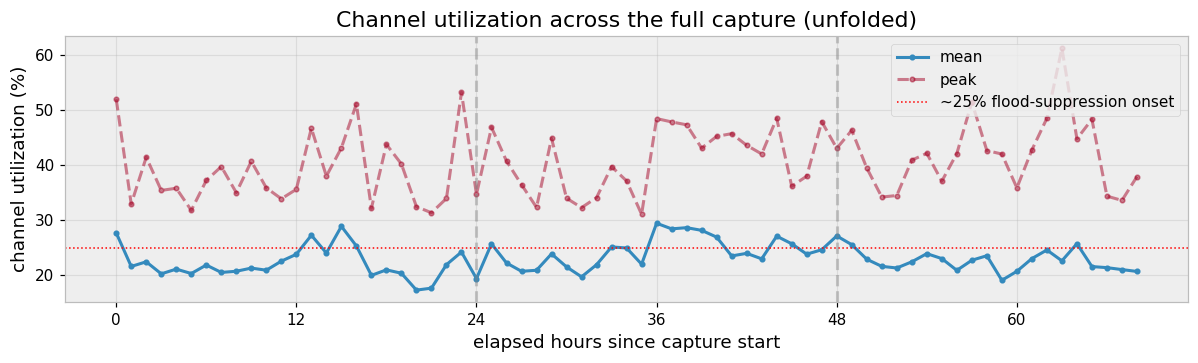

In [3]:
u = q("""SELECT CAST((t - (SELECT MIN(t) FROM utilization))/3600 AS INT) elapsed_hr,
                 AVG(ch_util) avg_util, MAX(ch_util) max_util
          FROM utilization WHERE ch_util IS NOT NULL
          GROUP BY elapsed_hr ORDER BY elapsed_hr""")

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(u.elapsed_hr, u.avg_util, marker=".", label="mean")
ax.plot(u.elapsed_hr, u.max_util, marker=".", ls="--", alpha=0.5, label="peak")
ax.axhline(25, color="red", ls=":", lw=1, label="~25% flood-suppression onset")

max_hr = int(u.elapsed_hr.max())
step = 12 if max_hr > 48 else (6 if max_hr > 24 else 3)
ax.set_xticks(range(0, max_hr + 1, step))
for day_end in range(24, max_hr + 1, 24):
    ax.axvline(day_end, color="gray", ls="--", alpha=0.4)

ax.set_xlabel("elapsed hours since capture start")
ax.set_ylabel("channel utilization (%)")
ax.set_title("Channel utilization across the full capture (unfolded)")
ax.legend(loc="upper right")
plt.tight_layout()

print(f"capture span: {max_hr} hours ({max_hr/24:.1f} days)")
print(f"mean utilization: {u.avg_util.mean():.1f}%   "
      f"hourly means range: {u.avg_util.min():.1f}-{u.avg_util.max():.1f}%   "
      f"highest peak: {u.max_util.max():.1f}%")

**Result.** Utilization never drops to idle. Hourly means hold in the low-to-mid 20s
percent around the clock, with peaks up to 60%. The channel sits *continuously* at or
above the flood-suppression threshold. This is the opposite of the "lightly loaded" intuition.
And, the explanation is aperture, not local congestion. A high site with a clear horizon
hears, and its channel is occupied by, the aggregate beacon traffic of the entire visible
mesh. **Utilization is a property of the aperture, not just the neighborhood.** A wide
aperture is, by construction, a busy one.

## 4 · Finding 2 - and it is talking to itself

A busy channel begs a question. Busy with *what*? If the mesh were carrying
conversation, high utilization would mean people communicating. We decompose every received
packet by application port. Encrypted packets (`?`) are private-channel traffic the node
cannot decrypt, but their *type* is overwhelmingly the same automated beaconing, just on
keyed channels. A node relays and counts them without reading them. Open Research Institute's
retention policy is that we keep only metadata, never payloads.

          portnum    n  pct
    TELEMETRY_APP 7610 27.2
                ? 7228 25.8
     POSITION_APP 6178 22.1
     NODEINFO_APP 5910 21.1
STORE_FORWARD_APP  713  2.5
 TEXT_MESSAGE_APP  200  0.7
      ATAK_PLUGIN  163  0.6
   RANGE_TEST_APP    1  0.0
   PAXCOUNTER_APP    1  0.0
  NODE_STATUS_APP    1  0.0

human text (TEXT_MESSAGE_APP): 0.7% of all traffic


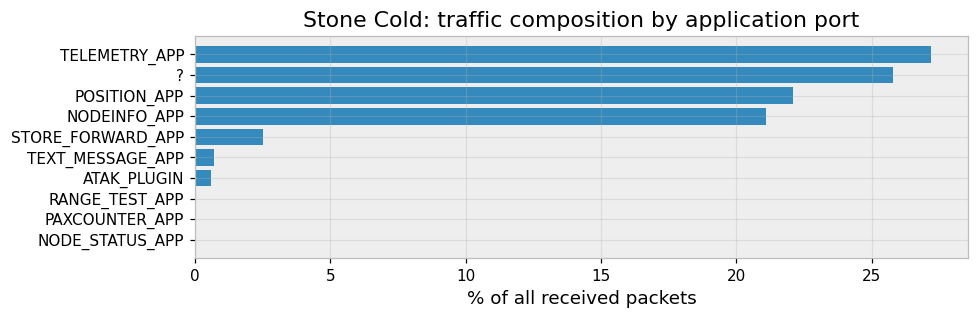

In [4]:
p = q("""SELECT portnum, COUNT(*) n,
                 ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM rx_log),1) pct
          FROM rx_log GROUP BY portnum ORDER BY n DESC""")
print(p.to_string(index=False))
human = p.loc[p.portnum=="TEXT_MESSAGE_APP","pct"].sum()
fig, ax = plt.subplots(figsize=(9,3))
ax.barh(p.portnum[::-1], p.pct[::-1])
ax.set_xlabel("% of all received packets")
ax.set_title("Stone Cold: traffic composition by application port")
plt.tight_layout()
print(f"\nhuman text (TEXT_MESSAGE_APP): {human}% of all traffic")

**Result.** Discuss results and repercussions here. 
Human text is **0.7%** of received traffic. The rest is machines announcing
themselves: telemetry, position, node-info, store-and-forward, and the encrypted 
slice, which carries the same beacon types on private channels.
The channel is about 25% utilized and **~99% of that load is automated overhead.**

Put the two findings together: the mesh's channel, at this aperture, is busy around the
clock, and it is busy carrying almost nothing anyone typed. The traffic the preset debates
argue over optimizing (human message delivery) is a rounding error riding on a channel
saturated with the network's own metabolism. 

## 5 · The instrument's own footprint

The disclosure from Section 1, quantified. A node configured to originate nothing still
transmits, because stock firmware relays. How much? `air_util_tx` is the node's own transmit
airtime.

In [5]:
tx = q("SELECT AVG(air_util_tx) a, MIN(air_util_tx) lo, MAX(air_util_tx) hi FROM utilization WHERE air_util_tx IS NOT NULL")
print(f"self transmit airtime: mean {tx.a[0]:.1f}%  (range {tx.lo[0]:.1f}-{tx.hi[0]:.1f}%)")

self transmit airtime: mean 4.1%  (range 2.0-5.7%)


**Result.** A "receive-only" monitoring node contributed several percent of transmit
airtime as a default relay. Two consequences: 
(a) the instrument lightly perturbs the channel it measures and this is an observer effect 
worth stating. 
(b) it illustrates the overhead mechanism at the single-node level. 

Flooding means every participating node re-radiates its neighbors' traffic. This is 
how aggregate overhead compounds into the busy channel of Finding 1. For a future 
pure-observation deployment, `rebroadcastMode` can be disabled or the role set to 
a non-relaying mode. That is a deliberate design choice, noted here for the fleet.

## 6 · Finding 3 - the humans are there, barely, and on a clock

Finding 2 showed human text is about 0.7% of traffic, but *is it there at all*, and does it
behave like people? The aggregate packet rate (Finding 1) is diurnally flat because the
machine baseline never sleeps. If we isolate the tiny text fraction, do we recover a human
rhythm? The site is US Pacific (UTC-7), so a human day should show a trough in the small
hours (roughly 09-13 UTC = 02-06 Pacific) and activity climbing through the morning.

mean text/hr, local night (09-13 UTC): 6.6
mean text/hr, local morning: 16.2


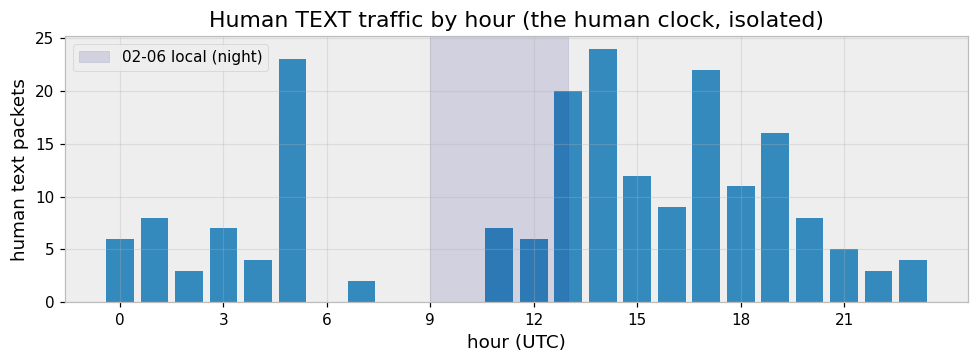

In [6]:
# --- parameter (set once, near the top of the notebook with DB) ---
UTC_OFFSET = -7          # site's offset from UTC (US Pacific PDT = -7)
NIGHT_LOCAL = (2, 6)     # local-clock hours considered "deep night"

# --- derived: convert local night window to UTC hours for the plot ---
night_utc_start = (NIGHT_LOCAL[0] - UTC_OFFSET) % 24   # 2 - (-7) = 9
night_utc_end   = (NIGHT_LOCAL[1] - UTC_OFFSET) % 24   # 6 - (-7) = 13

t = q("""SELECT strftime('%H', t_rx,'unixepoch') hr, COUNT(*) txt
          FROM rx_log WHERE portnum='TEXT_MESSAGE_APP' GROUP BY hr ORDER BY hr""")
t["hr"] = t.hr.astype(int)
allhr = pd.DataFrame({"hr": range(24)}).merge(t, on="hr", how="left").fillna(0)

fig, ax = plt.subplots()
ax.bar(allhr.hr, allhr.txt)
ax.axvspan(night_utc_start, night_utc_end, alpha=0.12, color="navy",
           label=f"{NIGHT_LOCAL[0]:02d}-{NIGHT_LOCAL[1]:02d} local (night)")
ax.set_xlabel("hour (UTC)"); ax.set_ylabel("human text packets")
ax.set_title("Human TEXT traffic by hour (the human clock, isolated)")
ax.set_xticks(range(0, 24, 3)); ax.legend(loc="upper left")
plt.tight_layout()

night = allhr[(allhr.hr >= night_utc_start) & (allhr.hr <= night_utc_end)].txt.mean()
day   = allhr[(allhr.hr >= night_utc_end) & (allhr.hr <= night_utc_end+3)].txt.mean()
print(f"mean text/hr, local night ({night_utc_start:02d}-{night_utc_end:02d} UTC): {night:.1f}")
print(f"mean text/hr, local morning: {day:.1f}")

**Result.** This independently re-derives the site's timezone from traffic alone, reproducing the technique 
that pinned the DEFCON 34 captures in MAHALO-1. 
**The method generalizes: whatever machine traffic dominates an aperture, the human clock is still there underneath, and port-filtering usually recovers it.**

## 7 · The aperture itself

Why does one radio see all this? The site. We characterize the aperture two ways. First, how many
distinct nodes it heard. And, second, the signal-strength distribution of what it heard. A high, clear
site should show both a large node count and a strong-SNR distribution relative to a
low/cluttered site.

distinct nodes heard in log: 729
receptions at -10 dB or stronger: 21%  (same radio in a suburb sat almost entirely below -15 dB)


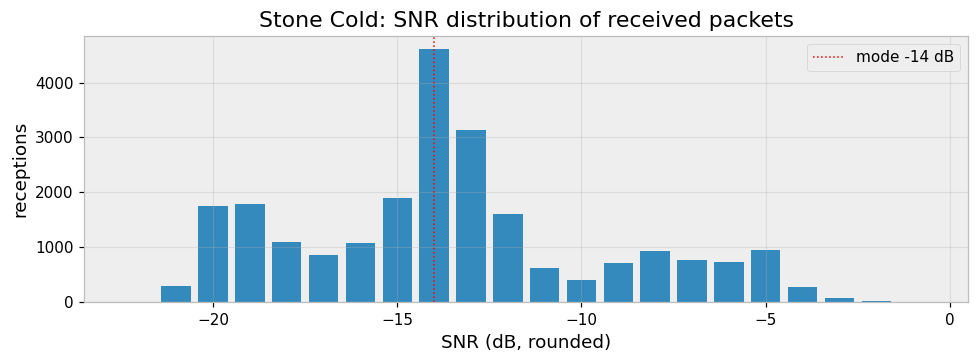

In [7]:
nodes = q("SELECT COUNT(DISTINCT from_id) n FROM rx_log WHERE from_id IS NOT NULL").n[0]
print(f"distinct nodes heard in log: {nodes}")
snr = q("SELECT ROUND(snr) s, COUNT(*) n FROM rx_log WHERE snr IS NOT NULL GROUP BY s ORDER BY s")
fig, ax = plt.subplots()
ax.bar(snr.s, snr.n)
mode_s = int(snr.s[snr.n.idxmax()])
ax.axvline(mode_s, color="red", ls=":", lw=1, label=f"mode {mode_s} dB")
ax.set_xlabel("SNR (dB, rounded)"); ax.set_ylabel("receptions")
ax.set_title("Stone Cold: SNR distribution of received packets")
ax.legend()
plt.tight_layout()
strong = 100*snr[snr.s>=-10].n.sum()/snr.n.sum()
print(f"receptions at -10 dB or stronger: {strong:.0f}%  "
      f"(same radio in a suburb sat almost entirely below -15 dB)")

**Result.** During this log, the radio heard **~729 distinct nodes** a large fraction of an
entire regional mesh, from a single location. And, with an SNR distribution centred well above the
decode floor and a substantial strong-signal population. The same radio and antenna in a
suburban location heard a fraction of the nodes, almost all near the noise floor. **Siting,
not hardware, dominates what a Meshtastic node perceives.** The instrument didn't get better.
The aperture did.

## 8 · What this means

Three measured claims, each against intuition:

- **Utilization is aperture-dependent and can be high.** A wide-aperture site runs its
  channel at ~25% around the clock. It is not lightly loaded at all. The utilization is that
  high because it integrates a metro's worth of beacon traffic. "How busy is the mesh?" has
  no single answer. It depends entirely on where you listen.
- **Load is ~99% overhead.** The busy channel carries almost no human communication. Whatever
  a preset choice optimizes for message delivery, it is optimizing a channel dominated by the
  network's own self-announcement, and not by conversation.
- **The human signal is real, tiny, and recoverable.** Port-filtering pulls a clean human
  diurnal out from under the machine baseline. This is a reusable technique across sites and events.

**For the Sending Stones delivery-ratio (PDR) program**, this is the fourth aperture regime,
alongside the dense-event captures (DEF CON 34, MAHALO-1, MAHALO-2) and the quiet suburban bench. It
supplies a *rural/high-elevation* operating point the framework needs. And, it reframes the
question the whole effort started from. The LongFast-vs-ShortTurbo debate assumed a saturated
channel carrying human traffic worth protecting. The measured reality at this aperture is a
channel already near the congestion threshold from *overhead*, with human traffic a rounding
error. And, at the pathological extreme (DEFCON 34's re-origination storm), the same axis runs
to genuine collapse. The useful question is not "which preset wins" but "how loaded is this
aperture, and with what". This is something only measurement, not intuition, can answer.

*No delivery ratio is computed here: this is a single passive aperture with no controlled
offered load. Characterizing what a station hears is the ceiling of passive analysis;
measuring what is delivered requires the controlled-probe experiment (`DESIGN.md`).*

**Reproduce:** place `your-log-file.sqlite` beside this notebook, set `DB`, Kernel -> Restart &
Run All. Data and notebook are published together under the project repository.